## 3D Spatial Interpolation in Neural Processes

In [1]:
import neuralprocesses as nps
import numpy as np
import torch
import matplotlib.pyplot as plt
import random

#### Generate a dense vector field for testing

This should be a field of 2d vectors in a 3d grid.

In [2]:
b_size = 16
x_size = 20
y_size = 20
z_size = 6

(16, 20, 20, 6, 2)


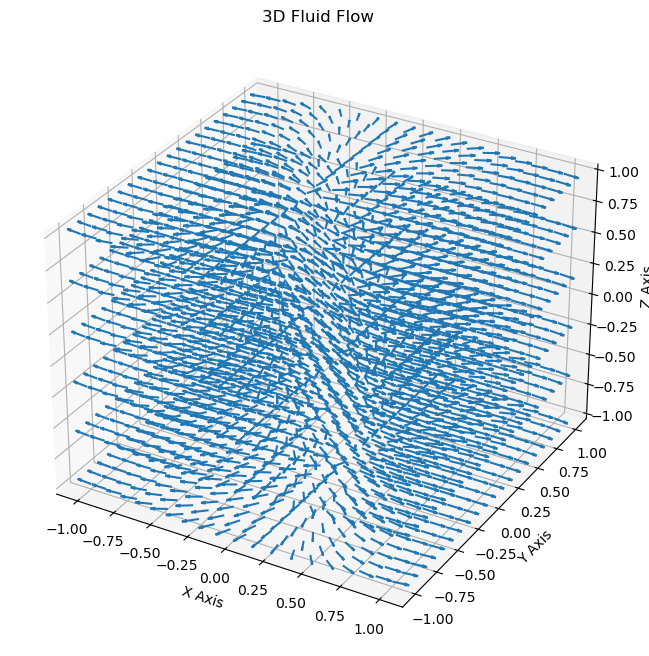

In [3]:
def random_velocity_field(batch, dim_x, dim_y, dim_z):
    velocity_field_batch = np.zeros((batch, dim_x, dim_y, dim_z, 2))  # shape: (batch, dim_x, dim_y, dim_z, 2)
    print(velocity_field_batch.shape)
    for b in range(batch):
        x, y, z = np.meshgrid(np.linspace(-1, 1, dim_x),
                        np.linspace(-1, 1, dim_y),
                        np.linspace(-1, 1, dim_z))

        # apply a function to create a more complex flow pattern
        u = random.randrange(0, 2)/10 * np.sin(random.random() * z) + np.sin(random.random() * x) * np.cos(random.random() * y)
        v = random.randrange(0, 2)/10 * np.cos(random.random() * z) + 0.5 * np.cos(np.pi * random.random() * x) * np.sin(np.pi * random.random() * y)
        w = np.zeros_like(z) # no vertical flow

        velocity_field = np.stack((u, v), axis=-1)  # shape: (dim_x, dim_y, dim_z, 3)
        velocity_field_batch[b, :, :, :] = velocity_field

    return velocity_field_batch

velocity_field_batch = random_velocity_field(b_size, x_size, y_size, z_size)

x, y, z = np.meshgrid(np.linspace(-1, 1, x_size), np.linspace(-1, 1, y_size), np.linspace(-1, 1, z_size))
u = velocity_field_batch[0, :, :, :, 0]  # shape: (x_size, y_size, z_size)
v = velocity_field_batch[0, :, :, :, 1]  # shape: (x_size, y_size, z_size)
w = np.zeros_like(u)  # shape: (x_size, y_size)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(x, y, z, u, v, w, length=0.1, normalize=True)

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Fluid Flow')
plt.show()

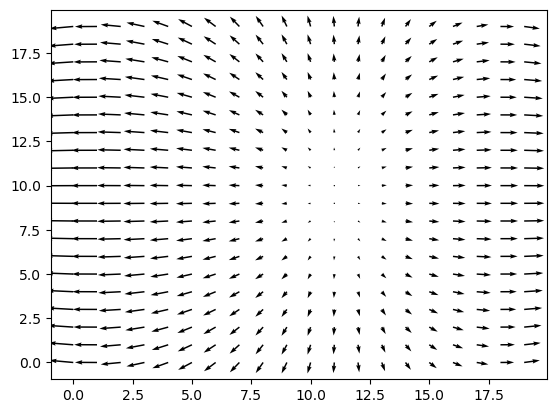

In [4]:
level = 0

plt.quiver(velocity_field_batch[0, :, :, level, 0], velocity_field_batch[0, :, :, level, 1])

#### pass through neuralprocesses

In [5]:
import lab.torch as B
import neuralprocesses.torch as nps

In [6]:
torch.set_default_device("cuda")
B.set_global_device("cuda")

In [7]:
#mib_usage = 8*100*100*25*2*4 /1024/1024
#print(f"Memory usage: {mib_usage:.2f} MiB")

In [8]:
cnp = nps.construct_convgnp(
    dim_x=3,
    dim_yc=(2,),
    dim_yt=2,
    likelihood="lowrank", 
    conv_arch="unet-res-sep", 
    unet_channels=(4, 4), 
    unet_kernels=5,
    points_per_unit=5)

x, y, z = torch.meshgrid(
    torch.linspace(-1, 1, x_size),
    torch.linspace(-1, 1, y_size),
    torch.linspace(-1, 1, z_size),
    indexing='ij'
)

xc_grid = torch.stack((x, y, z), dim=0)  
# (3, x, y, z)

xc_grid = xc_grid.unsqueeze(0).repeat(b_size, 1, 1, 1, 1)

yc_grid = torch.tensor(velocity_field_batch, dtype=torch.float32)  # shape: (x_size, y_size, z_size, 2)
yc_grid = yc_grid.permute(0, 4, 1, 2, 3)

xt = xc_grid

# mask some inputs
mask = torch.ones(b_size, x_size, y_size, z_size, dtype=torch.float32)

# mask out 50% of the points randomly
mask = mask.flatten(1)  # shape: (b_size, x_size * y_size * z_size)
for i in range(mask.shape[0]):
    indices = torch.randperm(mask.shape[1])[:mask.shape[1] // 2]
    mask[i, indices] = 0
    
mask = mask.view(b_size, x_size, y_size, z_size)  # shape: (b_size, x_size, y_size, z_size)
mask = mask.unsqueeze(1) # shape: (b_size, 1, x_size, y_size, z_size) to match yc_grid's shape

# now I want mask shape to be (b_size, 2, x_size, y_size, z_size) to match yc_grid's shape
#mask = mask.repeat(1, 2, 1, 1, 1)

In [12]:
xc = xc_grid.reshape(b_size, 3, -1)
yc = yc_grid.reshape(b_size, 2, -1)
xt = xt.reshape(b_size, 3, -1)
mask_flat = mask.reshape(b_size, 1, -1)

pred = cnp(
    [(xc, nps.Masked(yc, mask_flat))],
    xt
)

In [13]:
pred

<MultiOutputNormal: shape=torch.Size([2, 2400])
 vectorised_normal=<Normal:
                    mean=<dense matrix: batch=(16,), shape=(4800, 1), dtype=torch.float32
                          mat=[[[-1.094]
                                [-1.095]
                                [-1.094]
                                ...
                                [ 6.26 ]
                                [ 6.259]
                                [ 6.23 ]]
                              
                               [[-1.094]
                                [-1.096]
                                [-1.096]
                                ...
                                [ 6.272]
                                [ 6.272]
                                [ 6.238]]
                              
                               [[-1.094]
                                [-1.095]
                                [-1.095]
                                ...
                                [ 6.266]
      